### 第13章 直方图处理
#### 13.1 绘制直方图
- 直方图是图像内灰度值的统计特性与图像灰度值之间的函数，直方图统计图像内各个灰度级出现的次数
- 横坐标是图像中个像素点的灰度级；纵坐标是具有该灰度级(像素值)的像素个数
- 根据以上关系可以绘制折线图和直方图，一般把折线图和直方图都称为直方图
- 在实际处理中，x轴区间一般是[0, 255]，对应8位位图的256个灰度级；y轴对应的是具有相应灰度级像素点的个数
    - DIMS 表示绘制直方图时收集的参数数量，一般情况下该值为1，即只有一种，就是灰度级
    - RANGE 表示要统计的灰度级范围，一般为[0, 255]。0 对应的是黑色，255 对应的是白色
    - BINS 是参数子集的数目。在处理过程中，有时需要将数据划分为若干组再进行分析

- `matplotlib.pyplot.hist(X, BINS)`用来根据数据源和灰度级分组绘制直方图，其中
    - X 是数据源。对于二维图像需要使用`ravel()`将图像处理为一维数据源，再作为参数使用
    - BINS 表示灰度级的分组情况

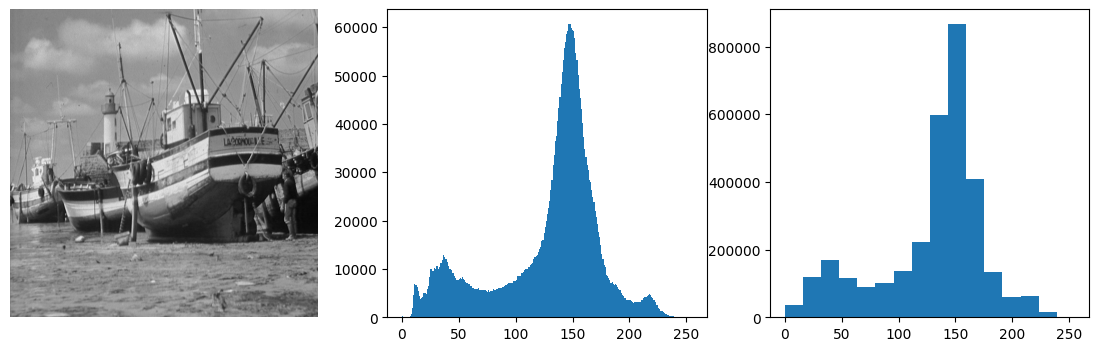

In [7]:
import cv2
import matplotlib.pyplot as plt
o = cv2.imread("boat.jpg")
plt.figure(figsize=(14, 4))
plt.subplot(131)
plt.imshow(o)
plt.axis('off')

plt.subplot(132)
plt.hist(o.ravel(), 256)    # 按照256个灰度级分组
plt.subplot(133)
plt.hist(o.ravel(), 16)     # 灰度级分为16个子集
plt.show()

- 函数`hist = cv2.calcHist(images, cnhannels, mask, histSize, ranges, accumulate)`用于统计图像直方图信息
    - hist 表示返回的统计直方图，是一维数组，数组内的元素是各个灰度级的像素个数
    - images 是原始图像集合，由`[]`括起来
    - channels 指定通道编号，同样需要`[]`括起来。灰度图为[0]；彩色图像是[0]、[1]、[2]。多个图像通道编号连续排列
    - mask 是掩膜图像，用于指定需要计算直方图的区域。当统计整幅图时，该值设为`None`
    - histSize 表示通道中对应的BINS的值
    - ranges 是像素范围，注意这是一个半开区间[lower, upper)，即包含下限但不包含上限。
    - accumulate 是累计标识，默认为`False`。设置为`True`时，开始计算直方图时不会清零，而是得到多个直方图的累计结果

- `matplotlib.pyplot.plot()`函数的`color`属性：
    - `b`: blue 蓝色
    - `g`: green 绿色
    - `r`: red 红色
    - `c`: cyan 蓝绿
    - `m`: magenta 洋红
    - `y`: yellow 黄色
    - `k`: black 黑色
    - `w`: white 白色
- `matplotlib.pyplot.plot()`函数的`marker`属性：
    - `.`: 点标记
    - `,`: 像素标记
    - `o`: 圆标记
    - `s`: 方形标记
    - `p`: 五边形标记
    - `*`: 星号标记
    - `h`, `H`: 垂直/水平六边形 标记
    - `+`: 加号 
    - `x`: X 符号
    - `D`, `d`: 钻石/瘦钻石 标记
    - `|`, `_`: 竖线/横线 标记
    - `v`, `^`, `<`, `>`: 下三角形/上三角形/左三角形/右三角形 标记
    - `1`, `2`, `3`, `4`: 下三角形/上三角形/左三角形/右三角形 (线条构成) 标记

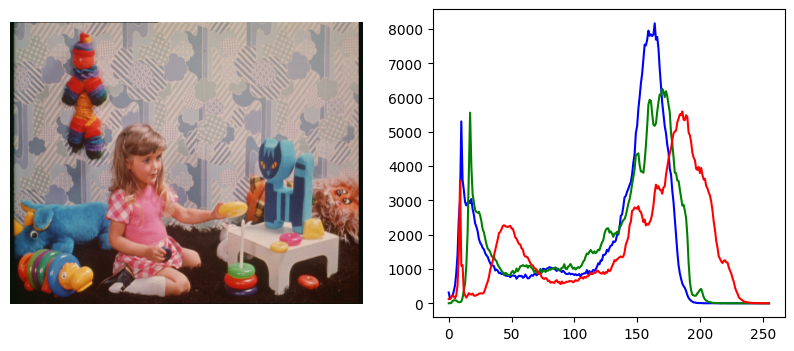

In [ ]:
# 绘制彩色图像的各个通道的直方图
import cv2
import matplotlib.pyplot as plt
o = cv2.imread("girl.bmp")
histb = cv2.calcHist([o], [0], None, [256], [0,256])
histg = cv2.calcHist([o], [1], None, [256], [0,256])
histr = cv2.calcHist([o], [2], None, [256], [0,256])


plt.figure(figsize=(10,4))
plt.subplot(121)
plt.imshow(cv2.cvtColor(o, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(122)
plt.plot(histb, color='b')
plt.plot(histg, color='g')
plt.plot(histr, color='r')
plt.show()

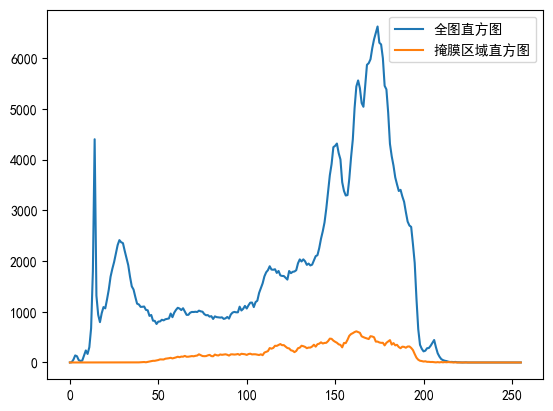

In [33]:
# 使用掩膜绘制直方图
import cv2
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei", "Arial"]    # 显示中文
plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

image = cv2.imread("girl.bmp", cv2.IMREAD_GRAYSCALE)
mask = np.zeros(image.shape, np.uint8)
mask[200:400,200:400] = 255     # 不要求必须是255，非零值即可
histImage = cv2.calcHist([image], [0], None, [256], [0,256])
histMI = cv2.calcHist([image], [0], mask, [256], [0,256])
plt.plot(histImage, label='全图直方图')
plt.plot(histMI, label='掩膜区域直方图')
plt.legend(['全图直方图', '掩膜区域直方图'])
plt.show()

#### 13.2 直方图均衡化
- 直方图均衡化的目的是将原始图像的灰度级均匀地映射到整个灰度级范围内，得到一个灰度级分布均匀的图像
- 直方图均衡化算法主要包括两个步骤：
    1. 计算累计直方图
    2. 对累计直方图进行区间转换
- 在原有范围内实现均衡化
$$ 像素值 = \left( 当前灰度级最大值 - 1 \right) \times 累计概率 $$
- 在更广泛的范围内实现均衡化
$$ 新的灰度级 = 更广范围灰度级最大值 \times 当前灰度级累计概率 $$